### [K線捕手](https://www.facebook.com/kevinyang20180801)  

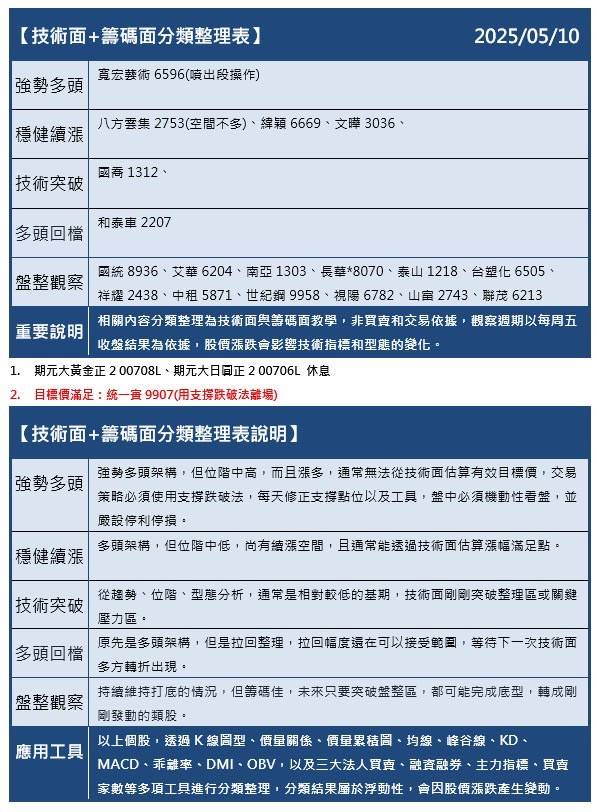  

### 本日進度  
* 量化技術分析系統：規劃與開發  
  - 價格資料更新程序驗證  

In [1]:
import os
import sys
import pandas as pd
import datetime
import sqlite3
import requests
import time

from dotenv import load_dotenv, find_dotenv
from FinMind.data import DataLoader

In [2]:
### 更新：近期資料 ###

# API 使用次數
def api_usage() :
    url = "https://api.web.finmindtrade.com/v2/user_info"
    payload = {
        "token": token,
    }
    resp = requests.get(url, params=payload)
    return resp.json()["user_count"],resp.json()["api_request_limit"]

# python 取得時間範圍內日期列表
# 來源：https://www.cnblogs.com/xiao-xue-di/p/11900649.html
def date_range(beginDate, endDate):
    dates = []
    dt = datetime.datetime.strptime(beginDate, "%Y-%m-%d")
    date = beginDate[:]
    while date <= endDate:
        dates.append(date)
        dt = dt + datetime.timedelta(1)
        date = dt.strftime("%Y-%m-%d")
    return dates

# 取得範圍日期列表(2025年5月7日至2025年5月8日)
price_date_list = date_range('2025-05-05', '2025-05-09')

In [3]:
# 設定FinMind API
load_dotenv(find_dotenv())
token = os.environ.get('FINMIND_TOKEN')
api = DataLoader()
api.login_by_token(api_token=token)

In [4]:
# 連線資料庫
conn = sqlite3.connect('data/stock.db')
cursor = conn.cursor()

In [5]:
# 確認外鍵支持
conn.execute('PRAGMA foreign_keys = ON;')

res = conn.execute('PRAGMA foreign_keys;')
res.fetchone()

(1,)

In [6]:
# 從資料庫中載入「台股總覽 TaiwanStockInfo」
df_stock_info = pd.read_sql("SELECT * FROM StockInfo", conn)
display(df_stock_info)

,StockID,StockName,IndustryCategory,Type
0,0050,元大台灣50,ETF,twse
1,0051,元大中型100,ETF,twse
2,0052,富邦科技,ETF,twse
3,0053,元大電子,ETF,twse
4,0054,元大台商50,ETF,twse
...,...,...,...,...
2934,TAIEX,加權指數,大盤,twse
2935,Textiles,紡織纖維類指數,Index,twse
2936,Tourism,觀光事業類指數,Index,twse
2937,TPEx,櫃買指數,大盤,tpex


In [7]:
# 更新資料庫
for price_date in price_date_list :
    
    # API 使用次數 #
    user_count,api_request_limit = api_usage()
    if user_count > (api_request_limit - 100) :
        print('抓取資料速度過快（user_count＝ {} ，api_request_limit ＝ {}），等三十分鐘後再行抓取'.format(user_count,api_request_limit))
        time.sleep(30*60)
        
    # 股價日成交資訊 TaiwanStockPrice：一次拿特定日期，所有資料(只限 backer、sponsor 使用) #
    sqlcmd = "SELECT * FROM DailyPrice WHERE Date='{}'".format(price_date)
    df     = pd.read_sql_query(sqlcmd, conn)
    if df.empty is True :
        while True :
            try :
                df = api.taiwan_stock_daily(start_date=price_date,)
            except Exception as e:
                print('日K：日期{}發生錯誤{}，重試'.format(price_date,e))
                continue
            break
        if df.empty is not True :
            print('日K：{}'.format(price_date))
            df_daily_price = df.drop(columns=['spread','Trading_turnover'])
            df_daily_price = df_daily_price.rename(columns={'date':'Date','stock_id':'StockID','Trading_Volume':'Volume','Trading_money':'Value','open':'Open','max':'High','min':'Low','close':'Close'})
            # 保存格式：日期、股票代碼、開盤價、最高價、最低價、收盤價、成交量與成交值
            df_daily_price = df_daily_price[['Date', 'StockID', 'Open', 'High', 'Low', 'Close', 'Volume', 'Value']]
            # 排除掉非TaiwanStockInfo內的股票
            df_daily_price = df_daily_price[df_daily_price['StockID'].isin(df_stock_info['StockID'].to_list())]
            df_daily_price.to_sql('DailyPrice', conn, if_exists='append', index=False)
        else :    
            time.sleep(1)
    else :
        print('日K：日期{}資料已存在於資料庫中'.format(price_date))
        time.sleep(1)
    
    # 台股週 K 資料表 TaiwanStockWeekPrice (只限 backer、sponsor 會員使用) ： 一次拿特定日期，所有資料(只限 backer、sponsor 使用) #
    sqlcmd = "SELECT * FROM WeeklyPrice WHERE Date='{}'".format(price_date)
    df     = pd.read_sql_query(sqlcmd, conn)
    if df.empty is True :
        url = "https://api.finmindtrade.com/api/v4/data"
        parameter = {
            "dataset": "TaiwanStockWeekPrice",
            "start_date": price_date,
            "token": token,
        }
        while True :
            resp = requests.get(url, params=parameter)
            if resp.status_code == 200 :
                break
            else :
                print('周K：日期{}發生錯誤，回應狀態碼 ＝ {}'.format(price_date,resp.status_code))
                if resp.status_code == 402 :
                    time.sleep(10*60)
        data = resp.json()
        df_weekly_price = pd.DataFrame(data["data"])
        if df_weekly_price.empty is not True :
            print('周K：{}'.format(price_date))
            df_weekly_price = df_weekly_price.drop(columns=['yweek','spread','trading_turnover'])
            df_weekly_price = df_weekly_price.rename(columns={'date':'Date','stock_id':'StockID','trading_volume':'Volume','trading_money':'Value','open':'Open','max':'High','min':'Low','close':'Close'})
            # 保存格式：日期、股票代碼、開盤價、最高價、最低價、收盤價、成交量與成交值
            df_weekly_price = df_weekly_price[['Date', 'StockID', 'Open', 'High', 'Low', 'Close', 'Volume', 'Value']]
            # 排除掉非TaiwanStockInfo內的股票
            df_weekly_price = df_weekly_price[df_weekly_price['StockID'].isin(df_stock_info['StockID'].to_list())]
            df_weekly_price.to_sql('WeeklyPrice', conn, if_exists='append', index=False)
        else :    
            time.sleep(1)
    else :
        print('周K：日期{}資料已存在於資料庫中'.format(price_date))
        time.sleep(1)
    
    # 台股月 K 資料表 TaiwanStockMonthPrice (只限 backer、sponsor 會員使用) ： 一次拿特定日期，所有資料(只限 backer、sponsor 使用) #
    sqlcmd = "SELECT * FROM MonthlyPrice WHERE Date='{}'".format(price_date)
    df     = pd.read_sql_query(sqlcmd, conn)
    if df.empty is True :
        url = "https://api.finmindtrade.com/api/v4/data"
        parameter = {
            "dataset": "TaiwanStockMonthPrice",
            "start_date": price_date,
            "token": token, 
        }
        while True :
            resp = requests.get(url, params=parameter)
            if resp.status_code == 200 :
                break
            else :
                print('月K：日期{}發生錯誤，回應狀態碼 ＝ {}'.format(price_date,resp.status_code))
                if resp.status_code == 402 :
                    time.sleep(10*60)
        data = resp.json()
        df_monthly_price = pd.DataFrame(data["data"])
        if df_monthly_price.empty is not True :
            print('月K：{}'.format(price_date))
            df_monthly_price = df_monthly_price.drop(columns=['ymonth','spread','trading_turnover'])
            df_monthly_price = df_monthly_price.rename(columns={'date':'Date','stock_id':'StockID','trading_volume':'Volume','trading_money':'Value','open':'Open','max':'High','min':'Low','close':'Close'})
            # 保存格式：日期、股票代碼、開盤價、最高價、最低價、收盤價、成交量與成交值
            df_monthly_price = df_monthly_price[['Date', 'StockID', 'Open', 'High', 'Low', 'Close', 'Volume', 'Value']]
            # 排除掉非TaiwanStockInfo內的股票
            df_monthly_price = df_monthly_price[df_monthly_price['StockID'].isin(df_stock_info['StockID'].to_list())]
            df_monthly_price.to_sql('MonthlyPrice', conn, if_exists='append', index=False)
        else :    
            time.sleep(1)
    else :
        print('月K：日期{}資料已存在於資料庫中'.format(price_date))
        time.sleep(1)

日K：日期2025-05-05資料已存在於資料庫中
周K：2025-05-05
日K：日期2025-05-06資料已存在於資料庫中


2025-05-11 14:22:32.954 | INFO     | FinMind.data.finmind_api:get_data:148 - download TaiwanStockPrice, data_id: 


日K：2025-05-07


2025-05-11 14:22:40.413 | INFO     | FinMind.data.finmind_api:get_data:148 - download TaiwanStockPrice, data_id: 


日K：2025-05-08


2025-05-11 14:22:48.108 | INFO     | FinMind.data.finmind_api:get_data:148 - download TaiwanStockPrice, data_id: 


日K：2025-05-09


In [8]:
# 修改並關閉資料庫
conn.commit()
conn.close()

In [9]:
##### 使用2025年3月31日到2025年5月9日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_2330_250511.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

In [10]:
# 比對：看盤軟體資料 #

# 顯示從看盤軟體過來的資料
display(df_k_line)

,Open,High,Low,Close,Volume
Date,,,,,
2025-03-31,920,924,910,910,59734
2025-04-01,929,946,925,944,33673
2025-04-02,949,952,938,942,28202
2025-04-07,848,848,848,848,37653
2025-04-08,797,843,797,816,136581
2025-04-09,809,826,780,785,122045
2025-04-10,863,863,863,863,28397
2025-04-11,848,889,836,889,81265
2025-04-14,895,903,865,865,72625


In [11]:
# 比對：從資料庫中取出相同範圍的資料 #

# 開啟資料庫
conn = sqlite3.connect('data/stock.db')

# 讀取區間大盤資料
price_db_df = pd.read_sql("SELECT * FROM DailyPrice WHERE StockID='2330' AND (Date BETWEEN '2025-03-31' AND '2025-05-09')", conn)

# 格式轉換：日期格式、成交量
price_db_df = price_db_df.drop(columns=['SerialNo','StockID','Value'])
price_db_df['Date'] = price_db_df['Date'].astype('datetime64[ns]')
price_db_df.set_index(price_db_df['Date'],inplace=True)
price_db_df = price_db_df.drop(columns=['Date'])
price_db_df['Volume'] = price_db_df['Volume'].div(1000)
price_db_df['Volume'] = price_db_df['Volume'].round()
price_db_df['Volume'] = price_db_df['Volume'].astype('int64')
display(price_db_df)

,Open,High,Low,Close,Volume
Date,,,,,
2025-03-31,920.0,924.0,910.0,910.0,59734
2025-04-01,929.0,946.0,925.0,944.0,33673
2025-04-02,949.0,952.0,938.0,942.0,28202
2025-04-07,848.0,848.0,848.0,848.0,37653
2025-04-08,797.0,843.0,797.0,816.0,136581
2025-04-09,809.0,826.0,780.0,785.0,122045
2025-04-10,863.0,863.0,863.0,863.0,28397
2025-04-11,848.0,889.0,836.0,889.0,81265
2025-04-14,895.0,903.0,865.0,865.0,72625


In [12]:
# 比對：看盤軟體與資料庫的價格資料 #

# 比對兩個不同來源是否相同
compare1_df = df_k_line.copy()
compare2_df = price_db_df.copy()
# 將資料庫中的價格都轉換成整數，以利比對
compare2_df['Open']   = compare2_df['Open'].astype('int64')
compare2_df['High']   = compare2_df['High'].astype('int64')
compare2_df['Low']    = compare2_df['Low'].astype('int64')
compare2_df['Close']  = compare2_df['Close'].astype('int64')

if compare1_df.equals(compare2_df) is True :
    print('☆ 看盤軟體與資料庫的價格資料相符')
else :
    print('★ 看盤軟體與資料庫的價格資料不符')

☆ 看盤軟體與資料庫的價格資料相符


In [13]:
# 修改並關閉資料庫
conn.close()